# Modelos LSTM - Vía de Ingreso Aerea

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams["figure.figsize"] = (14, 5)

## 1. Carga de Datos

Entrenamiento: 147 meses
Prueba: 63 meses


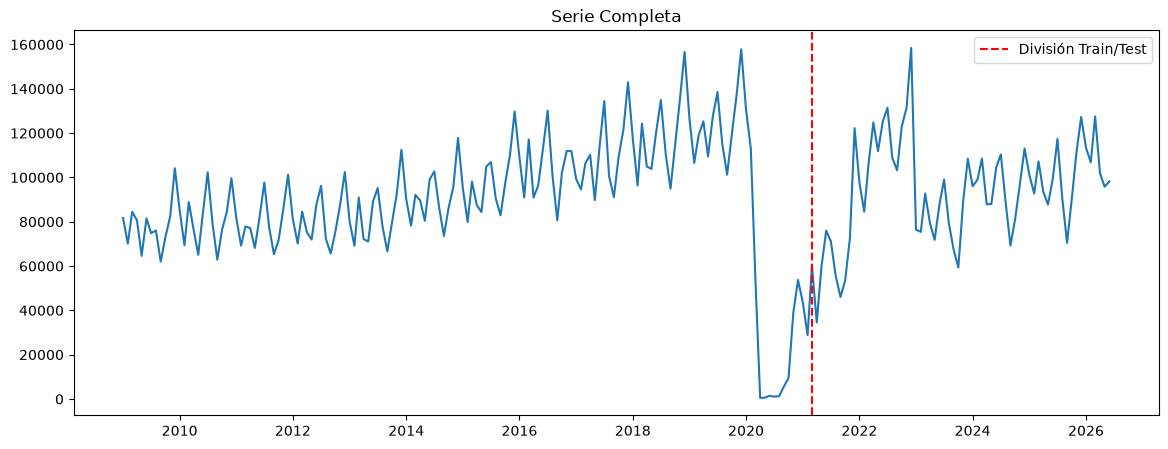

In [2]:
train = pd.read_csv('../../Datos/train_via_ingreso_aerea.csv', parse_dates=['Fecha'], index_col='Fecha')
test = pd.read_csv('../../Datos/test_via_ingreso_aerea.csv', parse_dates=['Fecha'], index_col='Fecha')

print(f"Entrenamiento: {len(train)} meses")
print(f"Prueba: {len(test)} meses")

# Concatenamos para facilitar el procesamiento secuencial
full_data = pd.concat([train, test])
plt.plot(full_data)
plt.axvline(x=train.index[-1], color='r', linestyle='--', label='División Train/Test')
plt.title('Serie Completa')
plt.legend()
plt.show()

## 2. Diferenciación (Estacionariedad) y Normalización

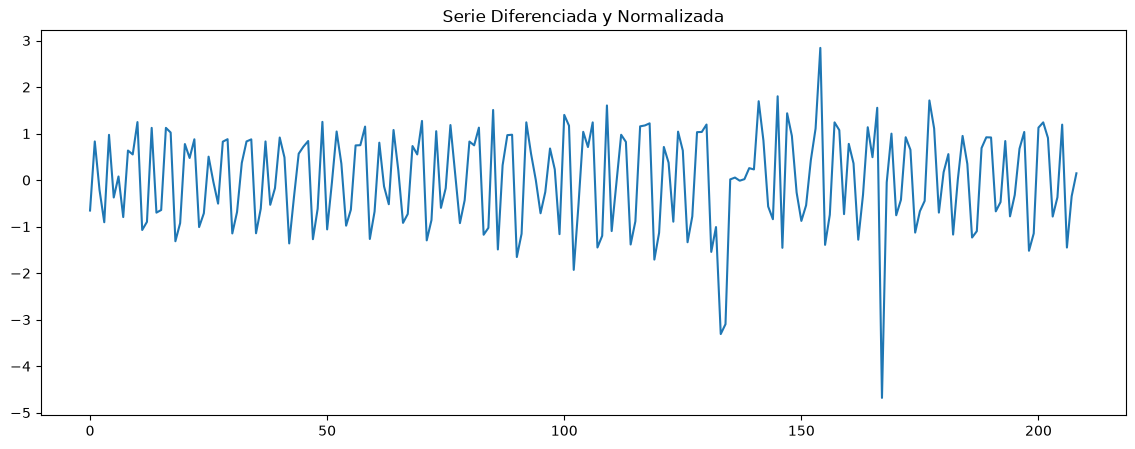

In [3]:
# Diferenciamos la serie para que sea más estacionaria (las redes LSTM lo prefieren)
serie_diff = full_data.diff().dropna()


train_size = len(train) - 1  # por la diferenciación
scaler = StandardScaler()
scaler.fit(serie_diff.iloc[:train_size])
serie_scaled = scaler.transform(serie_diff)

plt.plot(serie_scaled)
plt.title('Serie Diferenciada y Normalizada')
plt.show()

## 3. Preparación de Secuencias (Supervisada)

In [4]:
def supervisada(serie, retrasos=1):
    serie_x = []
    serie_y = []
    for i in range(len(serie)-retrasos):
        valor = serie[i:(i+retrasos), 0]
        valor_sig = serie[i+retrasos, 0]
        serie_x.append(valor)
        serie_y.append(valor_sig)
    return np.array(serie_x), np.array(serie_y)

## 4. Entrenamiento de Modelos
### Modelo 1: Configuración Conservadora (Ventana = 12 meses)

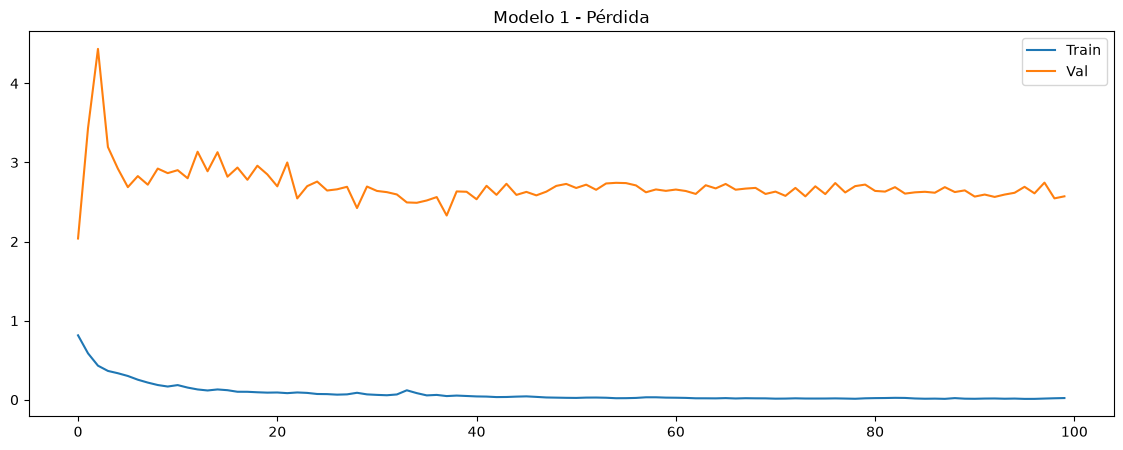

Pérdida en Test (MSE) Modelo 1: 0.9008


In [5]:
retrasos_m1 = 6
X_m1, y_m1 = supervisada(serie_scaled, retrasos_m1)

# División
# (train_size ya se calculó arriba, al ajustar el scaler)
X_train_m1 = X_m1[:train_size-retrasos_m1]
y_train_m1 = y_m1[:train_size-retrasos_m1]
X_test_m1 = X_m1[train_size-retrasos_m1:]
y_test_m1 = y_m1[train_size-retrasos_m1:]

# Reshape para Keras [muestras, paso, características]
X_train_m1 = np.reshape(X_train_m1, (X_train_m1.shape[0], X_train_m1.shape[1], 1))
X_test_m1 = np.reshape(X_test_m1, (X_test_m1.shape[0], X_test_m1.shape[1], 1))

modelo1 = keras.Sequential([
    layers.Input((retrasos_m1, 1)),
    layers.LSTM(32),
    layers.Dense(1)
])

modelo1.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(learning_rate=0.01))
hist1 = modelo1.fit(X_train_m1, y_train_m1, epochs=100, batch_size=8, validation_split=0.2, verbose=0)

plt.plot(hist1.history['loss'], label='Train')
plt.plot(hist1.history['val_loss'], label='Val')
plt.title('Modelo 1 - Pérdida')
plt.legend()
plt.show()

loss_m1 = modelo1.evaluate(X_test_m1, y_test_m1, verbose=0)
print(f"Pérdida en Test (MSE) Modelo 1: {loss_m1:.4f}")

### Modelo 2: Configuración Compleja (Ventana = 24 meses)

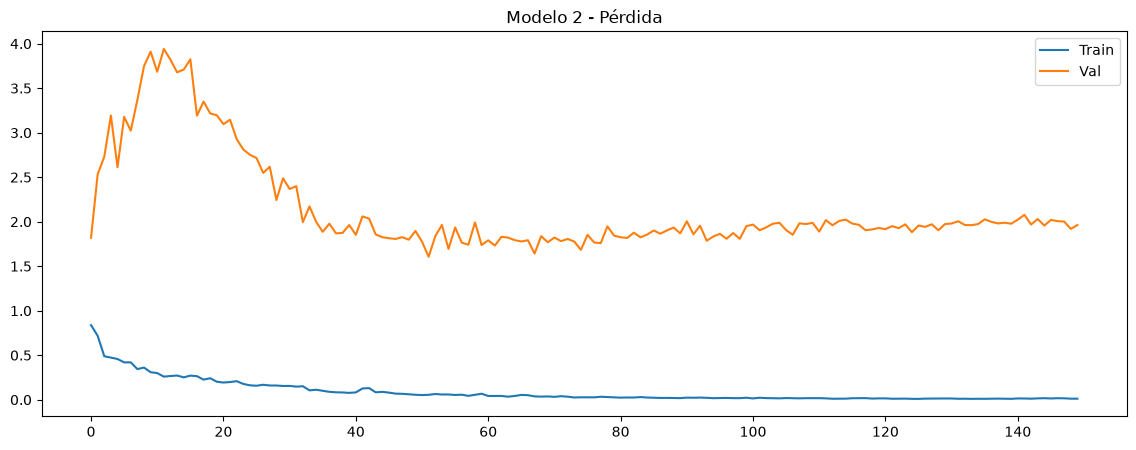

Pérdida en Test (MSE) Modelo 2: 1.5760


In [6]:
retrasos_m2 = 12
X_m2, y_m2 = supervisada(serie_scaled, retrasos_m2)

X_train_m2 = X_m2[:train_size-retrasos_m2]
y_train_m2 = y_m2[:train_size-retrasos_m2]
X_test_m2 = X_m2[train_size-retrasos_m2:]
y_test_m2 = y_m2[train_size-retrasos_m2:]

X_train_m2 = np.reshape(X_train_m2, (X_train_m2.shape[0], X_train_m2.shape[1], 1))
X_test_m2 = np.reshape(X_test_m2, (X_test_m2.shape[0], X_test_m2.shape[1], 1))

modelo2 = keras.Sequential([
    layers.Input((retrasos_m2, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(1)
])

modelo2.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(learning_rate=0.005))
hist2 = modelo2.fit(X_train_m2, y_train_m2, epochs=150, batch_size=16, validation_split=0.2, verbose=0)

plt.plot(hist2.history['loss'], label='Train')
plt.plot(hist2.history['val_loss'], label='Val')
plt.title('Modelo 2 - Pérdida')
plt.legend()
plt.show()

loss_m2 = modelo2.evaluate(X_test_m2, y_test_m2, verbose=0)
print(f"Pérdida en Test (MSE) Modelo 2: {loss_m2:.4f}")

## 5. Predicción con el Mejor Modelo


Comparación de Métricas:
                    Modelo      MAE     RMSE
 LSTM Modelo 1 (Ventana=6) 11,828.6 16,606.1
LSTM Modelo 2 (Ventana=12) 15,749.8 21,965.2
            Prophet (Lab1) 42,320.6 47,090.8
              ARIMA (Lab1) 73,980.4 77,694.0


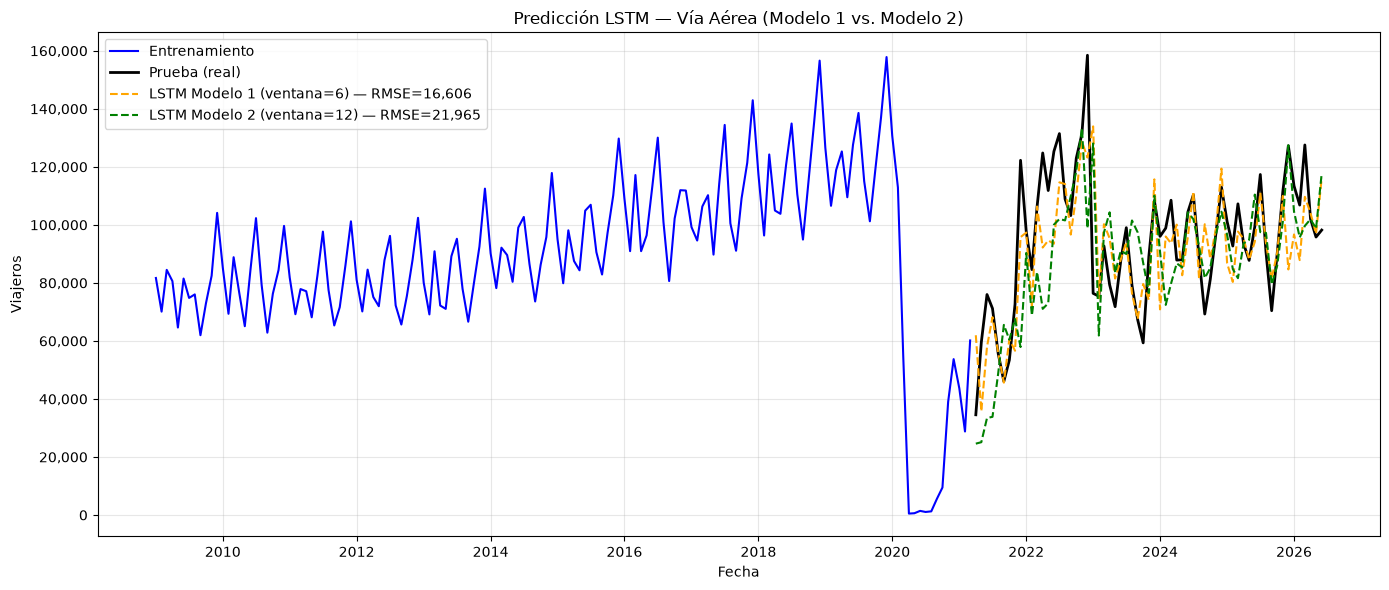


=> Mejor LSTM: Modelo 1


In [7]:
# Predecimos en test con ambos modelos
pred_scaled_m1 = modelo1.predict(X_test_m1, verbose=0)
pred_scaled_m2 = modelo2.predict(X_test_m2, verbose=0)

# Desnormalizamos
pred_diff_m1 = scaler.inverse_transform(pred_scaled_m1)
pred_diff_m2 = scaler.inverse_transform(pred_scaled_m2)

valores_reales = full_data.values

def desdiferenciar(pred_diff, train_size, retrasos):
    pred_original = []
    idx_inicio = train_size + 1
    for i in range(len(pred_diff)):
        idx_real = idx_inicio + i
        prev_val = valores_reales[idx_real - 1][0]
        pred_original.append(prev_val + pred_diff[i][0])
    return np.array(pred_original)

pred_original_m1 = desdiferenciar(pred_diff_m1, train_size, retrasos_m1)
pred_original_m2 = desdiferenciar(pred_diff_m2, train_size, retrasos_m2)

# Índices para el test
idx_inicio_test = train_size + 1
real_original = valores_reales[idx_inicio_test:]
fechas_test = full_data.index[idx_inicio_test:]

# Métricas finales
rmse_m1 = np.sqrt(mean_squared_error(real_original, pred_original_m1))
mae_m1 = mean_absolute_error(real_original, pred_original_m1)

rmse_m2 = np.sqrt(mean_squared_error(real_original, pred_original_m2))
mae_m2 = mean_absolute_error(real_original, pred_original_m2)

# Métricas extraídas del Laboratorio 1 (Vía Aérea)
mae_prophet, rmse_prophet = 42320.6, 47090.8
mae_arima, rmse_arima = 73980.4, 77694.0

comparacion = pd.DataFrame({
    'Modelo': ['LSTM Modelo 1 (Ventana=6)', 'LSTM Modelo 2 (Ventana=12)', 'Prophet (Lab1)', 'ARIMA (Lab1)'],
    'MAE':  [mae_m1, mae_m2, mae_prophet, mae_arima],
    'RMSE': [rmse_m1, rmse_m2, rmse_prophet, rmse_arima],
}).sort_values('RMSE')
print("\nComparación de Métricas:")

print(comparacion.to_string(index=False, float_format=lambda x: f"{x:,.1f}"))


import matplotlib.ticker as mticker

plt.figure(figsize=(14, 6))
# Plot train
plt.plot(full_data.index[:idx_inicio_test], valores_reales[:idx_inicio_test], label='Entrenamiento', color='blue')
# Plot test
plt.plot(fechas_test, real_original, label='Prueba (real)', color='black', linewidth=2)
# Plot preds
plt.plot(fechas_test, pred_original_m1, label=f'LSTM Modelo 1 (ventana=6) — RMSE={rmse_m1:,.0f}', linestyle='--', color='orange')
plt.plot(fechas_test, pred_original_m2, label=f'LSTM Modelo 2 (ventana=12) — RMSE={rmse_m2:,.0f}', linestyle='--', color='green')

# Configurar gráfica estilo La Aurora
nombre = 'Aérea'
plt.title(f'Predicción LSTM — Vía {nombre} (Modelo 1 vs. Modelo 2)')
plt.xlabel('Fecha')
plt.ylabel('Viajeros')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mejor_lstm = 'Modelo 1' if rmse_m1 < rmse_m2 else 'Modelo 2'
print(f"\n=> Mejor LSTM: {mejor_lstm}")